# Step 3. Preprocessing, EDA, and Feature Engineering

Step 2 showed what is in the data. Step 3 prepares it for modeling and studies what predicts dropout, using the right test for each feature type.

This notebook does six things.

1. Clean the data, and confirm the checks from Step 2 in code.
2. Split into train and test, so nothing downstream learns from the test set.
3. Explore each feature against dropout with the correct test for its type.
4. Engineer features from domain knowledge, and throw away the first one I built.
5. Select the strongest features, and actually drop the weak ones.
6. Build one preprocessing pipeline, fit on the training set only.

The leakage decision from Step 1 becomes code here. I drop the twelve curricular columns, so the model sees only what is known at enrollment.

Point 4 is the one worth reading. My first engineered feature looked excellent and was quietly breaking the model, and finding out why taught me more than the feature ever would have.

In [1]:
import sys
from pathlib import Path

for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "paths.py").exists():
        sys.path.insert(0, str(_p))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data import (
    load_binary,
    CONTINUOUS, BINARY_FLAGS, NOMINAL_CODED, COUNT_ORDINAL, LEAKAGE, TARGET,
)
from src.features import (
    engineer, linear_dependencies,
    MODEL_NUMERIC, MODEL_NOMINAL, MODEL_FLAGS, REPLACED, DROPPED,
)
from src.paths import ROOT

bdf = load_binary()

# I keep enrollment-time features only. The twelve curricular columns are the
# leakage from Step 1, so I leave them out here.
FEATURES = CONTINUOUS + BINARY_FLAGS + NOMINAL_CODED + COUNT_ORDINAL
X = bdf[FEATURES].copy()
y = bdf["dropout"]
print("features kept", len(FEATURES), "| leakage columns dropped", len(LEAKAGE))

features kept 24 | leakage columns dropped 12


## 1. Cleaning

Step 2 found no missing values and no duplicate rows. The providers cleaned the file before release, so this confirms it in code rather than inventing work. Real extremes, like mature student ages, stay, since they are true records, not errors.

In [2]:
print("null cells", int(X.isna().sum().sum()))
print("duplicate rows", int(X.duplicated().sum()))
print()
print("range check on true numbers")
print(X[CONTINUOUS].agg(["min", "max"]).round(1))

null cells 0
duplicate rows 0

range check on true numbers
     Previous qualification (grade)  Admission grade  Age at enrollment  \
min                            95.0             95.0                 17   
max                           190.0            190.0                 70   

     Unemployment rate  Inflation rate  GDP  
min                7.6            -0.8 -4.1  
max               16.2             3.7  3.5  


No null cells and no duplicate rows, as expected. Grades sit between 0 and 200, and ages run from 17 into mature entry. Nothing here needs removing. The mature ages are real students, not outliers to cut, so they stay.

## 2. Train and Test Split

I split now, before any feature work that looks at the outcome. This keeps the preparation honest. Everything that follows, the tests, the scaling, the encoding, is learned from the training set only. The test set stays back, unseen until Step 4.

The split is stratified on dropout, so both parts hold the same 39 percent rate, and the seed is fixed so the split is the same on every run.

In [3]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42,
)
print("train", Xtr.shape, "dropout rate", round(ytr.mean() * 100, 1), "percent")
print("test ", Xte.shape, "dropout rate", round(yte.mean() * 100, 1), "percent")

train (2904, 24) dropout rate 39.2 percent
test  (726, 24) dropout rate 39.1 percent


## 3. True Numbers Against Dropout

The six true numbers get compared between students who drop out and students who graduate. Grades and age are skewed, so the test is the Mann-Whitney U test, which compares two groups without assuming a normal shape. It asks whether the two groups differ, and returns a p-value. A small p-value means the difference is real, not chance.

The histograms show each number split by outcome, so the shape of the difference is visible.

Mann-Whitney U, each true number vs dropout (train)
  Age at enrollment                median gap      4.0   p=9.2e-65
  Admission grade                  median gap     -4.6   p=1.2e-16
  Previous qualification (grade)   median gap     -1.1   p=2.1e-14
  GDP                              median gap    -0.47   p=1.1e-03
  Inflation rate                   median gap      0.0   p=2.1e-01
  Unemployment rate                median gap      0.0   p=7.5e-01


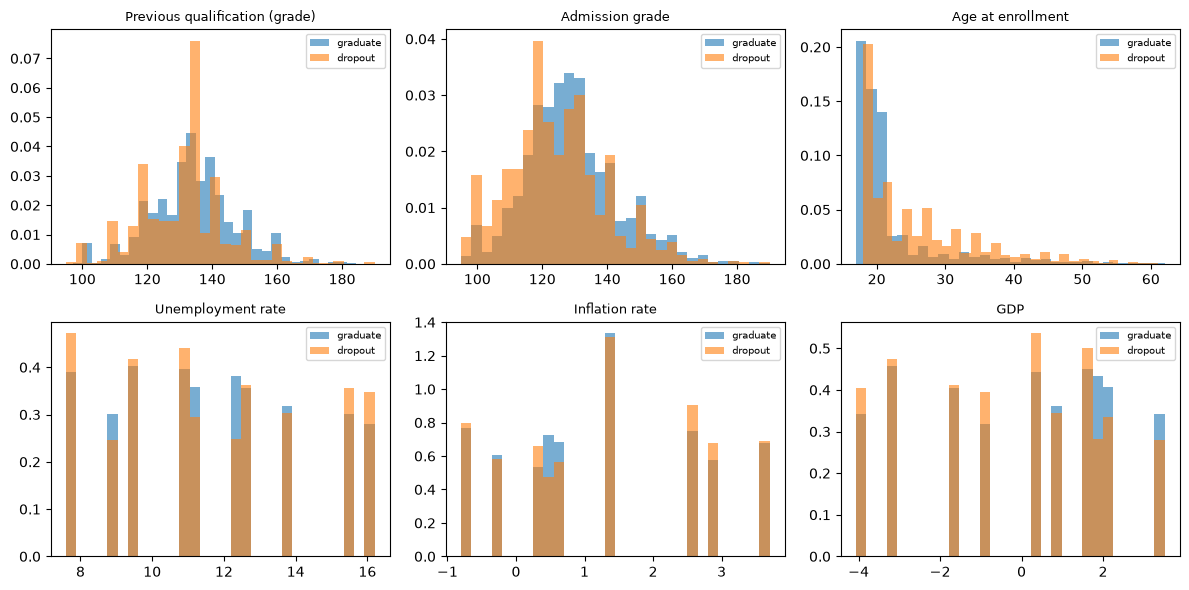

In [4]:
from scipy.stats import mannwhitneyu

print("Mann-Whitney U, each true number vs dropout (train)")
rows = []
for c in CONTINUOUS:
    a = Xtr.loc[ytr == 1, c]
    b = Xtr.loc[ytr == 0, c]
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    rows.append((c, round(a.median() - b.median(), 2), p))
for c, diff, p in sorted(rows, key=lambda r: r[2]):
    print(f"  {c:32} median gap {diff:8}   p={p:.1e}")

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, c in zip(axes.ravel(), CONTINUOUS):
    ax.hist(Xtr.loc[ytr == 0, c], bins=30, alpha=0.6, label="graduate", density=True)
    ax.hist(Xtr.loc[ytr == 1, c], bins=30, alpha=0.6, label="dropout", density=True)
    ax.set_title(c, fontsize=9)
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "continuous_by_dropout.png", dpi=90)
plt.show()

Age has the strongest and clearest link. Older entrants drop out more. Admission grade and previous qualification grade both matter, with lower grades tied to dropout. GDP has a weak link. Unemployment and inflation show no real difference, with p-values above 0.05, so they carry little signal on their own.

## 4. Categories Against Dropout

Categories need different tools than numbers. Three measures work together here, and it helps to know what each one does and where it comes from.

**Dropout rate per category.** The plain view. It shows the direction, which groups drop out more.

**Chi-square test.** From Karl Pearson, around 1900. It answers one yes or no question. Is the link between a category and dropout real, or could it be chance? It compares the counts seen against the counts expected if the two were unrelated, and returns a p-value. Its weakness is that it says nothing about strength. On a large sample almost any link passes as real, because the test grows with sample size.

**Cramer's V.** From Harald Cramer, 1946. It takes the chi-square number and rescales it to a 0 to 1 range, correcting for sample size and table shape. Now the result reads as strength. 0 is no link, 1 is a perfect link. Its weakness is the mirror of chi-square. It tells how strong, not whether it is beyond chance.

**Why not plain correlation.** Correlation measures a straight line link between two real numbers. On these coded categories it is wrong, since the codes are labels, not amounts. A course coded 9500 is not larger than one coded 33. This is the mistake the feature type routing exists to prevent.

**Which is better.** Neither alone. Chi-square answers is it real, Cramer's V answers how strong. Used together they rank features by a link that is both real and meaningful. On 3630 rows almost everything is significant, so Cramer's V does the real ranking for me. A rough guide for reading V, under 0.1 is negligible, 0.1 to 0.3 is weak, 0.3 to 0.5 is moderate, above 0.5 is strong.

In [5]:
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    table = pd.crosstab(a, b)
    chi2, p, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    v = np.sqrt((chi2 / n) / max(min(r, k) - 1, 1))
    return v, p

print("chi-square and Cramer's V, each category vs dropout (train)")
rows = []
for c in BINARY_FLAGS + NOMINAL_CODED:
    v, p = cramers_v(Xtr[c], ytr)
    rows.append((c, v, p))
for c, v, p in sorted(rows, key=lambda r: -r[1]):
    print(f"  {c:32} V={v:.3f}   p={p:.1e}")

chi-square and Cramer's V, each category vs dropout (train)
  Tuition fees up to date          V=0.437   p=1.4e-122
  Course                           V=0.346   p=4.7e-64
  Application mode                 V=0.330   p=1.0e-57
  Scholarship holder               V=0.321   p=5.7e-67
  Debtor                           V=0.269   p=1.7e-47
  Gender                           V=0.255   p=4.8e-43
  Mother's occupation              V=0.202   p=4.1e-13
  Mother's qualification           V=0.201   p=1.7e-13
  Previous qualification           V=0.199   p=1.4e-17
  Father's qualification           V=0.199   p=8.4e-12
  Father's occupation              V=0.187   p=1.1e-07
  Marital status                   V=0.112   p=8.9e-07
  Displaced                        V=0.108   p=6.3e-09
  Daytime/evening attendance       V=0.083   p=7.4e-06
  Nacionality                      V=0.072   p=5.9e-01
  International                    V=0.010   p=5.9e-01
  Educational special needs        V=0.002   p=8.9e-01


Tuition fees up to date tops the ranking at 0.437, well ahead of the rest. Course, application mode, scholarship holder, and debtor follow in the moderate range. Gender is moderate too. `Nacionality`, `International`, and educational special needs sit near zero with p-values above 0.05, so they carry almost no signal. All three come out in Section 7.

The next check looks at links between categories, to find columns that repeat the same information.

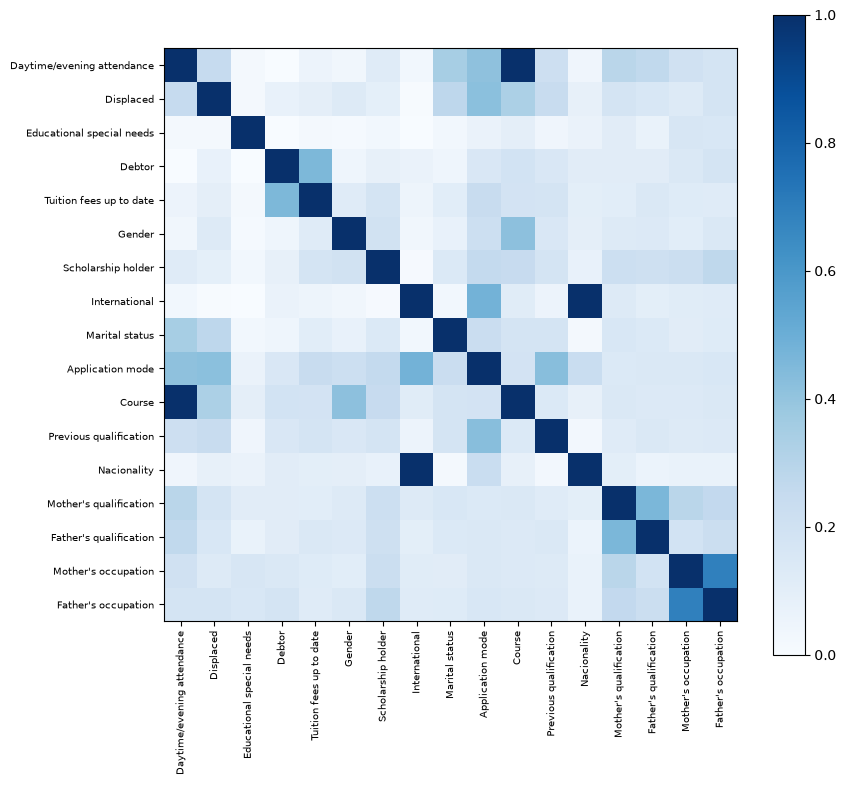

strongest category to category links
  Daytime/evening attendance + Course   V=1.000
  International + Nacionality   V=1.000
  Mother's occupation + Father's occupation   V=0.689
  International + Application mode   V=0.479


In [6]:
cats = BINARY_FLAGS + NOMINAL_CODED
M = pd.DataFrame(np.eye(len(cats)), index=cats, columns=cats)
for i, a in enumerate(cats):
    for j, b in enumerate(cats):
        if i < j:
            v, _ = cramers_v(Xtr[a], Xtr[b])
            M.iloc[i, j] = M.iloc[j, i] = v

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(M.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(cats))); ax.set_xticklabels(cats, rotation=90, fontsize=7)
ax.set_yticks(range(len(cats))); ax.set_yticklabels(cats, fontsize=7)
fig.colorbar(im); fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "cramers_v_matrix.png", dpi=90)
plt.show()

pairs = [(cats[i], cats[j], M.iloc[i, j]) for i in range(len(cats)) for j in range(len(cats)) if i < j]
print("strongest category to category links")
for a, b, v in sorted(pairs, key=lambda r: -r[2])[:4]:
    print(f"  {a} + {b}   V={v:.3f}")

Two pairs are perfectly linked, at V = 1.000. `International` repeats `Nacionality`, since one is derived from the other. Daytime or evening attendance is fixed by Course. Mother's and father's occupation overlap strongly, at 0.689, but not perfectly, so they carry some independent information.

A perfect link means one of the pair is not a second fact. It is the first fact, restated. I noted that here on the first pass and then moved on, which was a mistake, because a column that repeats another column does not sit there harmlessly. It corrupts the coefficients of the column it shadows. Section 6.1 comes back to both pairs with a proper test and drops them.

(The source file spells it `Nacionality`. I kept the typo rather than rename the column, so the names here match the names in the download.)

One more check guards the linear model. Multicollinearity, where true numbers move together, makes a linear model unstable. The variance inflation factor, VIF, measures it. A VIF near 1 is clean, above 5 is a concern.

In [7]:
corr = Xtr[CONTINUOUS].corr().values
vif = np.diag(np.linalg.inv(corr))
print("VIF on the six true numbers (train)")
for c, v in sorted(zip(CONTINUOUS, vif), key=lambda r: -r[1]):
    print(f"  {c:32} VIF={v:.2f}")

VIF on the six true numbers (train)
  Previous qualification (grade)   VIF=1.52
  Admission grade                  VIF=1.49
  GDP                              VIF=1.17
  Unemployment rate                VIF=1.14
  Age at enrollment                VIF=1.03
  Inflation rate                   VIF=1.03


Every VIF is under 2, with the highest near 1.5. The true numbers are close to independent, so the linear model is safe on this front, and nothing is dropped for multicollinearity.

VIF only looks at the six true numbers, though. It says nothing about the one-hot columns, or about any feature I might build later. Section 6 is where that gap turns out to matter.

## 5. The Tuition Status Check

Step 2 flagged tuition fees up to date as a near-outcome signal. Students not up to date drop out 94 percent of the time, and it tops the Cramer's V ranking. A student who has stopped paying is often a student already leaving, so the flag sits close to the outcome.

A quick logistic regression trains twice, once with the flag and once without, and the two get compared.

The comparison runs on cross-validation folds inside the training set. My first pass at this scored the two models on the held-out test set, which was wrong, and quietly so. Two sections up this notebook promises the test set stays sealed until Step 4, and then I broke that promise to settle a feature question. Any decision made by looking at test performance leaks test information into the model, however small the decision looks. Cross-validation answers the same question and keeps the promise.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(5, shuffle=True, random_state=42)

def quick_lr(cols):
    pre = ColumnTransformer([
        ("num", StandardScaler(), [c for c in CONTINUOUS + COUNT_ORDINAL if c in cols]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), [c for c in NOMINAL_CODED if c in cols]),
        ("flag", "passthrough", [c for c in BINARY_FLAGS if c in cols]),
    ])
    model = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=2000, class_weight="balanced"))])
    # Scored on training folds. Xte is not touched here, or anywhere before Step 4.
    pr = cross_val_score(model, Xtr[cols], ytr, cv=cv, scoring="average_precision").mean()
    roc = cross_val_score(model, Xtr[cols], ytr, cv=cv, scoring="roc_auc").mean()
    return pr, roc

with_t = quick_lr(FEATURES)
without_t = quick_lr([c for c in FEATURES if c != "Tuition fees up to date"])
print(f"with tuition     cv PR-AUC={with_t[0]:.3f}   cv ROC-AUC={with_t[1]:.3f}")
print(f"without tuition  cv PR-AUC={without_t[0]:.3f}   cv ROC-AUC={without_t[1]:.3f}")

with tuition     cv PR-AUC=0.817   cv ROC-AUC=0.848
without tuition  cv PR-AUC=0.765   cv ROC-AUC=0.826


Removing the flag drops cross-validated PR-AUC from 0.817 to 0.765, and ROC-AUC from 0.848 to 0.826. So it is a real contributor, and an expensive one to give up, but it is not the whole model. The model still works without it.

The flag stays. Five points of PR-AUC is far too much to hand back for a risk that is a judgement call rather than a demonstrated leak, and the curricular columns are the demonstrated leak.

It stays with a note attached, though. Tuition status is the single strongest thing this model knows, which means a school acting on it will be acting, in large part, on who is behind on payments. Step 5 comes back to what that means for the students it flags.

## 6. Feature Engineering, and the Feature I Threw Away

The first feature I built here was a socioeconomic pressure score. Add up three signs of money trouble, one point each. Owing the school money. Falling behind on tuition. Holding no scholarship. Zero means no strain, three means all of it.

The idea felt right and the numbers agreed. Mutual information ranked it first, ahead of every raw column in the file. So it went into the model.

Then the coefficients came back wrong. Not weak. Wrong. The model said that owing the school money makes a student **less** likely to drop out, and that holding a scholarship makes them **more** likely. The data says the opposite, and says it loudly. Working out why took a while, and the answer turned out to be the most useful thing in this notebook.

In [9]:
# The score, rebuilt so the problem is visible.
check = Xtr.copy()
check["socioeconomic pressure"] = (
    check["Debtor"]
    + (1 - check["Tuition fees up to date"])
    + (1 - check["Scholarship holder"])
)

# Rearrange that line and the three flags cancel. Whatever is left should vary
# from student to student. Watch what it actually does.
identity = (
    check["socioeconomic pressure"]
    - check["Debtor"]
    + check["Tuition fees up to date"]
    + check["Scholarship holder"]
)
print("pressure - Debtor + Tuition + Scholarship =", identity.unique())

pressure - Debtor + Tuition + Scholarship = [2]


One value. `[2]`. Not close to 2 on average. Exactly 2, on all 2904 training rows.

That is the whole problem in one line. The score is not new information. It is the three flags added together, and all three flags are already sitting in the design matrix. So the matrix now holds the same fact twice, and there is no unique answer to how much weight each column should carry. Any split that adds up correctly fits the data equally well.

The model still trains. The penalty picks one split out of the infinite number available, and it picks arbitrarily. That arbitrary split is what I had been reading as a coefficient.

`linear_dependencies` counts how often this is happening in a matrix.

In [10]:
def build_matrix(frame, numeric, nominal, flags):
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal),
        ("flag", "passthrough", flags),
    ])
    return pre, pre.fit_transform(frame)

pre_old, Z_old = build_matrix(
    check, CONTINUOUS + COUNT_ORDINAL + ["socioeconomic pressure"], NOMINAL_CODED, BINARY_FLAGS
)
print(f"columns              {Z_old.shape[1]}")
print(f"one-hot blocks       {len(NOMINAL_CODED)}")
print(f"exact dependencies   {linear_dependencies(Z_old)}")

columns              216
one-hot blocks       9
exact dependencies   19


216 columns, 9 one-hot blocks, 19 exact dependencies.

Nine of those nineteen are expected. A one-hot block that keeps every level always sums to the intercept, and there are nine such blocks, so nine dependencies come free with the encoding. The penalty absorbs those, and nobody reads a single dummy column on its own anyway.

The other ten are not expected. Ten places where a column repeats something the matrix already holds.

Here is what that does to the three flags the score was built from. Same model, same data. The only thing that changes is whether the score sits in the matrix next to them.

In [11]:
def coefficients(pre, Z):
    fit = LogisticRegression(max_iter=3000, class_weight="balanced").fit(Z, ytr)
    return pd.Series(fit.coef_[0], index=pre.get_feature_names_out())

pre_clean, Z_clean = build_matrix(Xtr, CONTINUOUS + COUNT_ORDINAL, NOMINAL_CODED, BINARY_FLAGS)
with_score = coefficients(pre_old, Z_old)
without_score = coefficients(pre_clean, Z_clean)

three = ["Debtor", "Scholarship holder", "Tuition fees up to date"]
actual = lambda c: f"{ytr[Xtr[c] == 1].mean():.0%} vs {ytr[Xtr[c] == 0].mean():.0%}"

pd.DataFrame({
    "coefficient, score in matrix": [round(with_score["flag__" + c], 3) for c in three],
    "coefficient, score removed": [round(without_score["flag__" + c], 3) for c in three],
    "actual dropout rate": [actual(c) for c in three],
}, index=three)

,"coefficient, score in matrix","coefficient, score removed",actual dropout rate
Debtor,-0.465,1.006,76% vs 34%
Scholarship holder,0.138,-1.344,14% vs 49%
Tuition fees up to date,-1.480,-2.913,31% vs 94%


Two signs flip.

Debtors drop out at 76 percent against 34 percent for everyone else. With the score in the matrix, the model gives Debtor a coefficient of **minus** 0.465, which reads as owing money being protective. Scholarship holders drop out at 14 percent against 49 percent, and the model gives Scholarship a coefficient of **plus** 0.138, which reads as the scholarship being a risk.

Take the score out and both land where the data says they should. Debtor at plus 1.006. Scholarship at minus 1.344.

This is why the feature had to go, and the reason is not the one I expected. It is not that the score hurt accuracy. It barely moved accuracy at all, because it never carried any information the model did not already have. What it did was make the model unreadable. Every explanation in Step 5 gets built from these coefficients, so a sign flip here becomes a sentence in Step 5 that tells a student the opposite of the truth.

A feature that costs nothing and explains nothing is not a harmless addition. It is a liability.

### 6.1 Two More Places the Matrix Repeats Itself

The rank check was worth running everywhere, not only on the feature I built. Section 4 already hinted at this, where the Cramer's V matrix showed two pairs sitting at a perfect 1.000. At the time I noted it and moved on. It deserved more than that.

In [12]:
same = (Xtr["International"] == (Xtr["Nacionality"] != 1).astype(int)).mean()
print(f"International equals (Nacionality != 1) on {same:.0%} of rows")

split = (pd.crosstab(Xtr["Course"], Xtr["Daytime/evening attendance"]) > 0).sum(axis=1)
print(f"courses running both a day and an evening class: {(split > 1).sum()} of {len(split)}")

International equals (Nacionality != 1) on 100% of rows
courses running both a day and an evening class: 0 of 17


`International` is not a second fact. It is `Nacionality` restated, on every single row.

And `Daytime/evening attendance` carries nothing of its own either, because the course decides it. Not one of the seventeen courses runs both a day and an evening class, so knowing the course already means knowing the attendance.

Both go. Neither loses anything, and both were quietly corrupting the coefficients of the columns they shadow, in exactly the way the pressure score was.

### 6.2 Features That Replace, Instead of Repeat

The rule I took from all of this is short. **A feature built out of columns that stay in the matrix adds nothing to a linear model.** The encoding already holds that information. So a feature earns its place only by replacing its sources, or by saying something the raw columns cannot say on their own.

Five features, built on that rule.

**`mother education tier`** and **`father education tier`** fold the parental qualification codes onto a ladder, 0 for cannot read up to 3 for higher education. The raw codes are thirty-odd nominal values that cost 63 dummy columns and throw away the only thing that matters about them, their order. The ladder keeps the order and costs two columns. It replaces both source columns.

**`first generation`** is on when neither parent reached higher education. This is the one feature here that says something genuinely new. Neither parent column shows it alone. It only appears once the two are read together, which is precisely what a raw one-hot cannot do. The education research has treated first-generation status as a dropout risk factor for decades.

**`mother isco`** and **`father isco`** fold the occupation codes down to ISCO major groups. The source mixes one-digit groups with three-digit detailed codes, and the first digit of a detailed code is its major group. Around sixty dummy columns become twelve.

**`application route`** folds eighteen application-mode codes into five routes an admissions officer would recognise. General contingent, over 23, transfer, international or special, other.

**`mature entry`** is on for students who enrol at 23 or older. Portugal runs a separate admission route at that age, Maiores de 23. Age already enters the model as a straight line, but dropout risk does not climb smoothly with age. It breaks at that route. A straight line cannot bend, so this flag bends it.

All of it lives in `src/features.py`, so Steps 4 and 5 read one definition instead of passing copies around. Nothing in there reads the outcome, so running it on train and on test applies the same fixed mapping and the test set stays clean.

In [13]:
Xtr, Xte = engineer(Xtr), engineer(Xte)

print("engineered:", [c for c in Xtr.columns if c not in FEATURES])
print("replaced:  ", REPLACED)
print("dropped:   ", DROPPED)

preprocessor, Z = build_matrix(Xtr, MODEL_NUMERIC, MODEL_NOMINAL, MODEL_FLAGS)
print(f"\ncolumns              {Z.shape[1]}  (was {Z_old.shape[1]})")
print(f"one-hot blocks       {len(MODEL_NOMINAL)}")
print(f"exact dependencies   {linear_dependencies(Z)}")

engineered: ['mother education tier', 'father education tier', 'first generation', 'mother isco', 'father isco', 'application route', 'mature entry']
replaced:   ["Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Application mode']
dropped:    ['Nacionality', 'International', 'Daytime/evening attendance', 'Educational special needs']

columns              84  (was 216)
one-hot blocks       6
exact dependencies   6


Dependencies equal blocks. Six and six.

That is the number I was after. Every dependency left in this matrix is one the encoding puts there by construction, and there are no others. Nothing repeats anything. Every coefficient in here can now be read for what it actually says, which is the whole basis of Step 5.

The column count fell from 216 to 84 on the way. That was not the goal, but it is a real dimensionality reduction, and it came from domain knowledge rather than from an algorithm. Section 8 checks what PCA can add on top of it.

## 7. Feature Selection

Filter selection ranks features by how much they tell about dropout, before any model is trained. The measure is mutual information, which captures any kind of dependence, not just a straight line, and works across mixed feature types. The categories are marked as discrete so their codes are read as labels, not amounts.

The ranking runs on the feature set the model will actually see, after the engineering in Section 6.

In [14]:
from sklearn.feature_selection import mutual_info_classif

cols = MODEL_NUMERIC + MODEL_NOMINAL + MODEL_FLAGS

# The nominal columns hold strings now, after the ISCO and route folding, so they
# get integer codes purely so mutual_info_classif can read them as labels.
encoded = Xtr[cols].copy()
for c in MODEL_NOMINAL:
    encoded[c] = encoded[c].astype("category").cat.codes

discrete = [c in MODEL_NOMINAL + MODEL_FLAGS for c in cols]
mi = pd.Series(
    mutual_info_classif(encoded, ytr, discrete_features=discrete, random_state=42),
    index=cols,
).sort_values(ascending=False)
mi.head(8).round(4)

Tuition fees up to date           0.1033
Age at enrollment                 0.0663
Course                            0.0623
Scholarship holder                0.0575
Previous qualification (grade)    0.0559
mature entry                      0.0534
application route                 0.0395
Debtor                            0.0360
dtype: float64

Tuition status leads at 0.103, which matches the Cramer's V ranking from Section 4. Age, course, and scholarship follow. `mature entry` comes in sixth at 0.053, above every raw column it was built from, which is the sign that bending the age term was worth doing.

Now for the part I got wrong the first time.

Last time I printed a ranking like this, nodded at it, wrote a sentence about which features were weakest, and then trained on every single one of them anyway. A ranking that changes nothing is not feature selection. It is a chart.

So this time the weak columns actually come out, and the cost gets measured rather than assumed. Four columns go. `Nacionality` and `International` because Section 6.1 showed they are the same column twice. `Daytime/evening attendance` because Course decides it. `Educational special needs` because it sits at the bottom of both this ranking and the Cramer's V table, and applies to a handful of students.

In [15]:
def cv_score(frame, numeric, nominal, flags):
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal),
        ("flag", "passthrough", flags),
    ])
    pipe = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=3000, class_weight="balanced"))])
    return cross_val_score(pipe, frame, ytr, cv=cv, scoring="average_precision").mean()

before = cv_score(Xtr, CONTINUOUS + COUNT_ORDINAL, NOMINAL_CODED, BINARY_FLAGS)
after = cv_score(Xtr, MODEL_NUMERIC, MODEL_NOMINAL, MODEL_FLAGS)

print(f"every raw feature        cv PR-AUC {before:.3f}   {Z_clean.shape[1]} columns")
print(f"engineered and selected  cv PR-AUC {after:.3f}    {Z.shape[1]} columns")

every raw feature        cv PR-AUC 0.817   215 columns
engineered and selected  cv PR-AUC 0.819    84 columns


Scored on cross-validation folds inside the training set, so the test set plays no part in this decision either.

Sixty percent of the columns are gone and the score went slightly **up**, 0.817 to 0.819. The gain is small enough to be noise, and that is fine. Cutting 131 columns for free is the result. A smaller matrix trains faster, generalises no worse, and produces a SHAP chart a human can actually read, which turns out to matter a great deal in Step 5.

## 8. Dimensionality Reduction with PCA

PCA compresses several correlated numbers into fewer combined ones. It fits true numbers only, since it relies on distance and order, which the coded categories do not have. Here it runs on the nine numerics the model now uses, which includes the two parental education ladders from Section 6.

Section 6 already cut the matrix from 216 columns to 84, using domain knowledge rather than an algorithm. The question here is whether PCA has anything left to add on top of that.

variance explained per component [np.float64(0.197), np.float64(0.168), np.float64(0.147), np.float64(0.135), np.float64(0.111), np.float64(0.079), np.float64(0.067), np.float64(0.051), np.float64(0.046)]
cumulative                      [np.float64(0.197), np.float64(0.365), np.float64(0.511), np.float64(0.647), np.float64(0.758), np.float64(0.837), np.float64(0.903), np.float64(0.954), np.float64(1.0)]
components holding 90 percent of the variance: 7 of 9


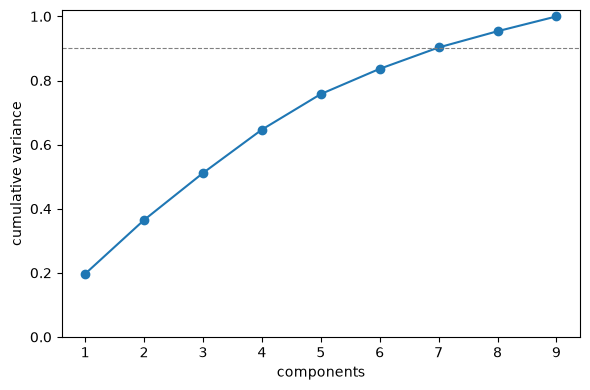

In [16]:
from sklearn.decomposition import PCA

Zn = StandardScaler().fit_transform(Xtr[MODEL_NUMERIC])
pca = PCA().fit(Zn)
cum = np.cumsum(pca.explained_variance_ratio_)
print("variance explained per component", [round(x, 3) for x in pca.explained_variance_ratio_])
print("cumulative                     ", [round(x, 3) for x in cum])
print(f"components holding 90 percent of the variance: {int(np.searchsorted(cum, 0.90) + 1)} of {len(cum)}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(cum) + 1), cum, marker="o")
ax.axhline(0.90, ls="--", lw=0.8, color="grey")
ax.set_xlabel("components"); ax.set_ylabel("cumulative variance"); ax.set_ylim(0, 1.02)
fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "pca_scree.png", dpi=90)
plt.show()

No component dominates, and it takes seven of the nine to reach 90 percent of the variance. That matches the low VIF from Section 4. The numerics are close to independent, so there is very little for PCA to compress.

Which is an honest result, not a failure. But leaving it there is not enough, and that is what I did last time. A scree plot that no model ever consumes is not a dimensionality reduction method used. It is a chart, same as the mutual information ranking was.

So PCA goes into Step 4 as a seventh model and has to earn its place against the other six. If it loses, that is a measured result and worth having. Step 4, Section 2.

## 9. The Preprocessing Pipeline

One pipeline holds all preparation. It scales the numerics, one-hot encodes the coded categories, and passes the flags through unchanged. It is fit on the training set only, so the test set stays untouched until Step 4.

The columns it takes come from `src/features.py`, not from a list retyped here, so Steps 4 and 5 cannot drift out of step with what Section 6 decided.

Two artifacts are saved. The fitted pipeline goes to models, and the engineered train and test frames go to data/processed. Step 4 loads these and never re-splits or re-fits preparation.

In [17]:
import joblib

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), MODEL_NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), MODEL_NOMINAL),
    ("flag", "passthrough", MODEL_FLAGS),
])
preprocessor.fit(Xtr)
print("prepared training shape", preprocessor.transform(Xtr).shape)
print("exact dependencies    ", linear_dependencies(preprocessor.transform(Xtr)),
      "| one-hot blocks", len(MODEL_NOMINAL))

(ROOT / "models").mkdir(exist_ok=True)
(ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
joblib.dump(preprocessor, ROOT / "models" / "preprocessor.joblib")
Xtr.assign(dropout=ytr.values).to_csv(ROOT / "data" / "processed" / "train.csv", index=False)
Xte.assign(dropout=yte.values).to_csv(ROOT / "data" / "processed" / "test.csv", index=False)
print("saved preprocessor.joblib and train.csv and test.csv")

prepared training shape (2904, 84)
exact dependencies     6 | one-hot blocks 6
saved preprocessor.joblib and train.csv and test.csv


## What Step 3 Settles

The base for Step 4 is ready.

1. Only enrollment-time features remain, since the twelve curricular columns are dropped as leakage.
2. The data is split, stratified on dropout, with the test set held back. Every decision in this notebook was made on training folds, including the tuition check, which I had originally settled by looking at the test set.
3. Age and grades are the strongest numbers, and tuition status, course, scholarship, and debtor are the strongest categories.
4. The socioeconomic pressure score was built, ranked first on mutual information, and then removed. It was a sum of three flags the matrix already held, it flipped the sign on two coefficients, and it would have made every explanation in Step 5 wrong.
5. Five features replaced their sources instead of sitting beside them, and four columns were dropped. The design matrix went from 216 columns and 19 exact dependencies to 84 columns and 6, which is exactly the number the one-hot encoding puts there by construction. Nothing repeats anything now.
6. One preprocessing pipeline is fit on train only and saved, with the split, for Step 4.

The lesson worth carrying forward is the one that cost the most to learn. A feature that adds no information cannot help a model, but it can still break it, and it breaks it in the place that matters most, which is the model's ability to say why.

Step 4 loads the saved split and pipeline, trains seven models including one on PCA components, and compares them.